# 代际交叠模型中的转型

除了 Anaconda 中的内容外，本讲座还需要以下库：

In [1]:
!pip install --upgrade quantecon

## 引言

本讲座介绍了由 Peter Diamond {cite}`diamond1965national` 提出的由”两期寿命人群的代际交叠”组成的生命周期模型。

我们将介绍Auerbach 和 Kotlikoff (1987) {cite}`auerbach1987dynamic`第二章中分析的版本。

Auerbach 和 Kotlikoff (1987)使用他们的两期模型作为预备，用来分析他们书中主要讨论的“长期寿命人群的代际交叠模型”。

他们的“两期寿命的代际交叠模型”是一个有用的起点,因为

* 它阐述了在给定日期存活的不同世代个体之间的互动结构
* 它揭示了政府及相继世代所面临的各种力量与权衡取舍。
* 它为研究政府税收与补贴政策之间的相互关系，以及政府债务发行与偿还政策，提供了一个良好的实验框架。
* 一些涉及从一个稳态到另一个稳态转变的有趣实验可以手工计算
* 它为展示**射击法**提供了一个合适的框架，该方法用于求解同时具有初始条件与终端条件的非线性差分方程组。

```{note}
Auerbach 和 Kotlikoff 使用计算机代码来计算他们的长寿人群模型的转换路径。
```

我们在 Auerbach 和 Kotlikoff 第二章模型的基础上作出扩展，用以研究跨世代资源再分配的一些制度安排。

  * 这些制度安排表现为一系列与年龄相关的定额税收与转移支付。

我们考察这些制度安排如何影响资本积累与政府债务。

## 设定

时间是离散的，用 $t=0, 1, 2, \ldots$ 表示。

经济体永远存在，但其中的人不会。

在每个时间点 $t \geq 0$，都有一个代表性老年人和一个代表性年轻人存活。
在时点 $t$，一个代表性老年人与一个代表性年轻人共存,这个年轻人将在时点 $t+1$ 成为老年人。

我们假设人口规模随时间保持不变。

年轻人从事工作，进行储蓄和消费。

老年人进行消费和储蓄，但不再劳动。

政府永远存在,即在各期 $t=0, 1, 2, \ldots$ 都存在。

每个时期 $t \geq 0$，政府进行征税、支出、转移支付和借贷。

在模型之外、于时点 $t=0$ 设定的初始条件为

* $K_0$：由一个代表性的初始老年人在时点 $t=0$ 时带入的初始资本存量
* $D_0$：由一个代表性的老年人在时点 $t=0$ 持有并在 $t=0$ 到期的政府债务
  
$K_0$ 和 $D_0$ 都以时点 $0$ 的商品单位计量。

政府**政策**由五个序列 $\{G_t, D_t, \tau_t, \delta_{ot}, \delta_{yt}\}_{t=0}^\infty$ 组成，其要素包括
* $\tau_t$：在时点 $t$ 对工资、资本收益和政府债券征收的统一税率
 * $D_t$：在时点 $t$ 到期的一期政府债券的本金,按人均计算
 * $G_t$：政府在时点 $t$ 的商品购买,按人均计算
 * $\delta_{yt}$：在时点 $t$ 对每个年轻人征收的一次性税
 * $\delta_{ot}$：在时点 $t$ 对每个老年人征收的一次性税


  
**配置**是一组序列 $\{C_{yt}, C_{ot}, K_{t+1}, L_t,  Y_t, G_t\}_{t=0}^\infty $，其组成部分包括

 * $K_t$：人均实物资本
 * $L_t$：人均劳动
 * $Y_t$：人均产出

以及

* $C_{yt}$：在时点 $t \geq 0$ 的代表性年轻人的消费
* $C_{ot}$：在时点 $t \geq 0$ 的代表性老年人的消费
* $K_{t+1} - K_t \equiv I_t $ -- 在时点 $t \geq 0$ 的实物资本投资
* $G_t$：政府购买

国民收入与产品核算由以下一组等式构成
* $Y_t = C_{yt} + C_{ot} + (K_{t+1} - K_t) + G_t, \quad t \geq 0$ 

**价格体系**是一对序列 $\{W_t, r_t\}_{t=0}^\infty$，其组成部分为生产要素的租赁价格

* $W_t$：在时点 $t \geq 0$ 的劳动要素租金
* $r_t$：在时点 $t \geq 0$ 的资本要素租金


## 生产

生产包含两种要素：实物资本 $K_t$ 和劳动投入 $L_t$。  

资本不会折旧。  

初始资本存量 $K_0$ 由一个代表性的初始老年人持有，并在时点 $0$ 出租给企业。

时点 $t$ 的净投资率 $I_t$ 为

$$
I_t = K_{t+1} - K_t
$$

时点 $t$ 的资本存量由过去投资的累计形成：

$$
K_t = K_0 + \sum_{s=0}^{t-1} I_s 
$$

生产函数采用 Cobb–Douglas 形式，将实物资本 $K_t$ 和劳动投入 $L_t$ 转化为产出 $Y_t$

$$
Y_t  = K_t^\alpha L_t^{1-\alpha}, \quad \alpha \in (0,1)
$$ (eq:prodfn)


## 政府
在时点 $t-1$，政府发行一期无风险债务，承诺在时点 $t$ 支付人均 $D_t$ 单位的商品。

时点 $t$ 的年轻人购买将于时点 $t+1$ 到期的政府债券 $D_{t+1}$。

在时点 $t$ 发行的政府债券，其税前净利率为 $r_{t}$，利息支付在时点 $t+1$ 进行。

政府在时点 $t \geq 0$ 的预算约束为

$$
D_{t+1} - D_t = r_t D_t + G_t - T_t
$$

或等价地

$$
D_{t+1} = (1 + r_t)  D_t + G_t - T_t  .
$$ (eq:govbudgetsequence) 

其中，总税收净额（扣除转移支付）为 $T_t$，满足

$$
T_t = \tau_t W_t L_t + \tau_t r_t (D_t + K_t) + \delta_{yt} + \delta_{ot}
$$


## 要素市场中的活动

**老年人：** 在每个时点 $t \geq 0$，一个代表性老年人

   * 将 $K_t$ 和 $D_t$ 带入当期，
   * 将资本出租给代表性企业，获得租金 $r_{t} K_t$，
   * 为其租金和利息收入缴税 $\tau_t r_t (K_t+ D_t)$，
   * 向政府缴纳一次性税款 $\delta_{ot}$，
   * 将 $K_t$ 卖给年轻人。  


  **年轻人：** 在每个时点 $t \geq 0$，一个代表性年轻人 
   * 向代表性企业出售一单位劳动服务，获得工资 $W_t$，
   * 为其劳动收入缴税 $\tau_t W_t$,
   * 向政府支付一次性税款 $\delta_{yt}$， 
   * 消费支出为 $C_{yt}$，
   * 获得非负资产 $A_{t+1}$，其中包括实物资本 $K_{t+1}$ 和在 $t+1$ 到期的一期政府债券 $D_{t+1}$ 之和。

```{note}
如果一次性税款为负，意味着政府向个人支付补贴。
``` 


## 代表性企业的问题 

代表性企业以竞争性工资率 $W_t$ 从年轻人那里雇佣劳动服务，并以竞争性租金率 $r_t$ 从老年人那里雇佣资本。 

资本的租金率 $r_t$ 等于政府一期债券的利率。

租金率的单位是：
* 对于 $W_t$，每单位劳动力在时点 $t$ 的产出  
* 对于 $r_t$，每单位资本在时点 $t$ 的产出 


我们将时点 $t$ 的产出作为*计价单位*，因此时点 $t$ 的产出价格等于1。

企业在时点 $t$ 的利润为 

$$
K_t^\alpha L_t^{1-\alpha} - r_t K_t - W_t L_t . 
$$

为了实现利润最大化，企业让边际产量与要素的租赁率相等：

$$
\begin{aligned}
W_t & = (1-\alpha) K_t^\alpha L_t^{-\alpha} \\
r_t & = \alpha K_t^\alpha L_t^{1-\alpha}
\end{aligned}
$$  (eq:firmfonc)

产出可以被老年人或年轻人消费；可以卖给年轻人用于增加资本存量；也可以卖给政府，用于不为个体带来效用的用途（在模型中，即“被丢入海洋”）。

因此，企业将产出出售给老年人、年轻人和政府。

## 个体问题

### 初始老年人
在时点 $t=0$,一个代表性的初始老年人拥有 $(1 + r_0(1 - \tau_0)) A_0$ 的初始资产。

他必须向政府支付一笔一次性税款（如果为正），或从政府获得补贴（如果为负） $\delta_{ot}$。

老年人的预算约束为

$$
C_{o0} = (1 + r_0 (1 - \tau_0)) A_0 - \delta_{ot} .
$$ (eq:hbudgetold)

初始老年人的效用函数为 $C_{o0}$,因此其最优消费计划由方程 {eq}`eq:hbudgetold` 给出。

### 年轻人

在每个时点 $t \geq 0$，代表性年轻人无弹性地提供一单位劳动，并获得税前劳动收入 $W_t$。

年轻人的税后与转移支付后的收入为 $W_t (1 - \tau_t) - \delta_{yt}$。

在每个时点 $t \geq 0$，年轻人选择消费计划 $C_{yt}, C_{o,t+1}$ 以最大化 Cobb–Douglas 效用函数

$$
U_t  = C_{yt}^\beta C_{o,t+1}^{1-\beta}, \quad \beta \in (0,1)
$$ (eq:utilfn)

其预算约束在 $t$ 和 $t+1$ 时分别为:

$$
\begin{aligned}
C_{yt} + A_{t+1} & =  W_t (1 - \tau_t) - \delta_{yt} \\
C_{o,t+1} & = (1+ r_{t+1} (1 - \tau_{t+1}))A_{t+1} - \delta_{ot}
\end{aligned}
$$ (eq:twobudgetc)

将{eq}`eq:twobudgetc` 的第二个方程解得的储蓄 $A_{t+1}$ 代入第一个方程，可得现值预算约束

$$
C_{yt} + \frac{C_{o,t+1}}{1 + r_{t+1}(1 - \tau_{t+1})} = W_t (1 - \tau_t) - \delta_{yt} - \frac{\delta_{ot}}{1 + r_{t+1}(1 - \tau_{t+1})}
$$ (eq:onebudgetc)

为了求解年轻人的最优问题，构建拉格朗日函数

$$ 
\begin{aligned}
{\mathcal L}  & = C_{yt}^\beta C_{o,t+1}^{1-\beta} \\ &  + \lambda \Bigl[ C_{yt} + \frac{C_{o,t+1}}{1 + r_{t+1}(1 - \tau_{t+1})} - W_t (1 - \tau_t) + \delta_{yt} + \frac{\delta_{ot}}{1 + r_{t+1}(1 - \tau_{t+1})}\Bigr],
\end{aligned}
$$ (eq:lagC)

其中 $\lambda$ 是跨期预算约束 {eq}`eq:onebudgetc` 的拉格朗日乘子。

经过若干代数运算，跨期预算约束 {eq}`eq:onebudgetc` 以及关于 $C_{yt}, C_{o,t+1}$ 最大化 ${\mathcal L}$ 的一阶条件表明，最优消费计划满足

$$
\begin{aligned}
C_{yt} & = \beta \Bigl[ W_t (1 - \tau_t) - \delta_{yt} - \frac{\delta_{ot}}{1 + r_{t+1}(1 - \tau_{t+1})}\Bigr] \\
\frac{C_{o,t+1}}{1 + r_{t+1}(1-\tau_{t+1})  } & = (1-\beta)   \Bigl[ W_t (1 - \tau_t) - \delta_{yt} - \frac{\delta_{ot}}{1 + r_{t+1}(1 - \tau_{t+1})}\Bigr] 
\end{aligned}
$$ (eq:optconsplan)

最小化拉格朗日函数 {eq}`eq:lagC` 关于拉格朗日乘子 $\lambda$ 的一阶条件可恢复预算约束 {eq}`eq:onebudgetc`，进而利用 {eq}`eq:optconsplan` 得到最优储蓄计划

$$
A_{t+1} = (1-\beta) [ (1- \tau_t) W_t - \delta_{yt}] + \beta \frac{\delta_{ot}}{1 + r_{t+1}(1 - \tau_{t+1})} 
$$ (eq:optsavingsplan)


(sec-equilibrium)=
## 均衡
**定义：** 均衡是一个由资源配置、政府政策和价格体系所组成的三元组，满足以下性质：
* 在给定价格体系与政府政策的条件下，该资源配置能解出：
    * $t \geq 0$ 时代表性企业的问题
    * $t \geq 0$时 的个体问题
* 在给定价格体系与资源配置的条件下，政府预算约束在所有 $t \geq 0$ 时都得到满足。


## 后续步骤


为开启对均衡结果的分析，我们将研究 Auerbach 和 Kotlikoff (1987) {cite}`auerbach1987dynamic` 在第2章开篇所采用的特例模型。

它可以手工求解。

我们接下来就将这样做。

在我们推导出封闭形式解之后，我们将假定自己事先并不知道解，并据此计算均衡路径。

具体而言，我们首先会将均衡表述为一个不动点问题：该不动点映射将要素价格与税率序列映射至要素价格与税率序列。

然后我们将通过迭代计算并收敛到该映射的不动点，从而得到均衡。


## 封闭形式解

为了得到 Auerbach 和 Kotlikoff (1987) {cite}`auerbach1987dynamic` 第2章的特例，我们将 $\delta_{ot}$ 和 $\delta_{yt}$ 都设为零。

作为 {eq}`eq:optconsplan` 的特例，代表性年轻人的消费–储蓄计划为：


$$
\begin{aligned}
C_{yt} & = \beta (1 - \tau_t) W_t \\
A_{t+1} &= (1-\beta) (1- \tau_t) W_t
\end{aligned}
$$

使用 {eq}`eq:firmfonc` 和 $A_t = K_t + D_t$，我们得到资本的封闭形式传导方程：

$$
K_{t+1}=K_{t}^{\alpha}\left(1-\tau_{t}\right)\left(1-\alpha\right)\left(1-\beta\right) - D_{t}\\
$$ (eq:Klawclosed)

### 稳态

根据 {eq}`eq:Klawclosed` 和政府预算约束 {eq}`eq:govbudgetsequence`，我们可以计算**时不变值**或**稳态值** $\hat K, \hat D, \hat T$：

$$
\begin{aligned}
\hat{K} &=\hat{K}\left(1-\hat{\tau}\right)\left(1-\alpha\right)\left(1-\beta\right) - \hat{D} \\
\hat{D} &= (1 + \hat{r})  \hat{D} + \hat{G} - \hat{T} \\
\hat{T} &= \hat{\tau} \hat{Y} + \hat{\tau} \hat{r} \hat{D} .
\end{aligned}
$$ (eq:steadystates)

这意味着

$$
\begin{aligned}
\hat{K} &= \left[\left(1-\hat{\tau}\right)\left(1-\alpha\right)\left(1-\beta\right)\right]^{\frac{1}{1-\alpha}} \\
\hat{\tau} &= \frac{\hat{G} + \hat{r} \hat{D}}{\hat{Y} + \hat{r} \hat{D}}
\end{aligned}
$$

示例：考虑以下情况：

1. 初始政府债务为零，即$D_t=0$，
2. 政府消费 $G_t$ 等于产出 $Y_t$ 的 $15\%$

由稳态公式可得

$$
\begin{aligned}
\hat{D} &= 0 \\
\hat{G} &= 0.15 \hat{Y} \\
\hat{\tau} &= 0.15 \\
\end{aligned}
$$



### 实现

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

from numba import jit
from quantecon.optimize import brent_max

给定参数 $\alpha = 0.3$ 和 $\beta = 0.5$，计算 $\hat{K}$：

In [3]:
# 参数
α = 0.3
β = 0.5

# τ 和 D 的稳态值
τ_hat = 0.15
D_hat = 0.

# 解 K 的稳态值
K_hat = ((1 - τ_hat) * (1 - α) * (1 - β)) ** (1 / (1 - α))
K_hat

0.17694509514972878

知道 $\hat K$ 后,我们可以计算其他均衡量。

首先，定义一些 Python 辅助函数。

In [4]:
@jit
def K_to_Y(K, α):

    return K ** α

@jit
def K_to_r(K, α):

    return α * K ** (α - 1)

@jit
def K_to_W(K, α):

    return (1 - α) * K ** α

@jit
def K_to_C(K, D, τ, r, α, β):

    # 当 δ=0 时老年人的最优消费
    A = K + D
    Co = A * (1 + r * (1 - τ))

    # 当 δ=0 时年轻人的最优消费
    W = K_to_W(K, α)
    Cy = β * W * (1 - τ)

    return Cy, Co

我们可以使用这些辅助函数来获得与稳态值 $\hat{K}$ 和 $\hat{r}$ 相对应的稳态值 $\hat{Y}$、$\hat{r}$ 和 $\hat{W}$。

In [5]:
Y_hat, r_hat, W_hat = K_to_Y(K_hat, α), K_to_r(K_hat, α), K_to_W(K_hat, α)
Y_hat, r_hat, W_hat

(0.5947734290747186, 1.0084033613445376, 0.41634140035230305)

由于政府债务的稳态值 $\hat{D}$ 为 $0$，所有税收都用于支付政府支出

In [6]:
G_hat = τ_hat * Y_hat
G_hat

0.0892160143612078

使用最优消费计划找到年轻人和老年人的消费稳态值

In [7]:
Cy_hat, Co_hat = K_to_C(K_hat, D_hat, τ_hat, r_hat, α, β)
Cy_hat, Co_hat

(0.17694509514972878, 0.32861231956378195)

使用一个名为 `init_ss` 的数组来存储稳态下的数量和价格

In [8]:
init_ss = np.array([K_hat, Y_hat, Cy_hat, Co_hat,     # 数量
                    W_hat, r_hat,                     # 价格
                    τ_hat, D_hat, G_hat               # 政策
                    ])

### 转型

我们已经计算了一个稳态，在该稳态下，政府政策序列在时间上都是常数。

我们将此稳态作为 $t=0$ 时另一个经济体的初始条件，在这个经济体中，政府政策序列随时间变化。

为便于理解计算，我们将 $t=0$ 理解为发生巨大、未预期冲击的时点，其形式包括

  * 随时间变化的政府政策序列扰乱了原有的稳态；
  * 新的政府政策序列最终在时间上收敛为常数，即在某一时点 $T >0$ 之后，每个序列在时间上保持不变；
  * 一项新的政府政策在 $t=0$ 时以政策序列的形式突然公布。

我们假设在 $t=0$ 时，包括老年人在内的每个人都知道新的政府政策序列，并据此做出选择。

随着资本存量和其他总量随时间对财政政策变化的调整，经济将接近一个新的稳态。

通过在序列空间中采用不动点算法，我们可以求解从旧稳态到新稳态的转型路径。

但在我们的特例中，由于存在封闭形式解，可采用一种更简单且更快速的方法。

为此，我们定义了一个 Python 类 `ClosedFormTrans`，其功能是在给定财政政策冲击下，计算长度为 $T$ 的转型路径。

我们选择足够大的 $T$，以确保在经过 $T$ 期后，经济已经非常接近新的稳态。

该类包含三个关键参数：`τ_pol`、`D_pol` 和 `G_pol`，分别是税率、政府债务水平和政府购买的序列。

在下面的每个政策实验中，我们将把三者中的两个作为输入，从而刻画一项财政政策。

接着，我们利用政府预算约束，计算唯一剩余的内生变量。

在模拟转型路径时，有必要区分**状态变量**（如时点 $t$ 的 $K_t,Y_t,D_t,W_t,r_t$）和**控制变量**（如 $C_{yt},C_{ot},\tau_{t},G_t$）。

In [9]:
class ClosedFormTrans:
    """
    本类用于模拟一个经济体在财政政策变化下的长度为 T 的转型路径，
    前提是给定其初始稳态。模拟基于在没有一次性税收情况下的封闭形式解。

    """

    def __init__(self, α, β):

        self.α, self.β = α, β

    def simulate(self,
                T,           # 要模拟的转型路径长度
                init_ss,     # 初始稳态
                τ_pol=None,  # 税率序列
                D_pol=None,  # 政府债务水平序列
                G_pol=None): # 政府购买序列

        α, β = self.α, self.β

        # 解包稳态变量
        K_hat, Y_hat, Cy_hat, Co_hat = init_ss[:4]
        W_hat, r_hat = init_ss[4:6]
        τ_hat, D_hat, G_hat = init_ss[6:9]

        # 初始化数组容器
        # K, Y, Cy, Co
        quant_seq = np.empty((T+1, 4))

        # W, r
        price_seq = np.empty((T+1, 2))

        # τ, D, G
        policy_seq = np.empty((T+2, 3))

        # t=0，从稳态开始
        K0, Y0 = K_hat, Y_hat
        W0, r0 = W_hat, r_hat
        D0 = D_hat

        # 财政政策
        if τ_pol is None:
            D1 = D_pol[1]
            G0 = G_pol[0]
            τ0 = (G0 + (1 + r0) * D0 - D1) / (Y0 + r0 * D0)
        elif D_pol is None:
            τ0 = τ_pol[0]
            G0 = G_pol[0]
            D1 = (1 + r0) * D0 + G0 - τ0 * (Y0 + r0 * D0)
        elif G_pol is None:
            D1 = D_pol[1]
            τ0 = τ_pol[0]
            G0 = τ0 * (Y0 + r0 * D0) + D1 - (1 + r0) * D0

        # 最优消费计划
        Cy0, Co0 = K_to_C(K0, D0, τ0, r0, α, β)

        # t=0 时的经济状态
        quant_seq[0, :] = K0, Y0, Cy0, Co0
        price_seq[0, :] = W0, r0
        policy_seq[0, :] = τ0, D0, G0
        policy_seq[1, 1] = D1

        # 从 t=1 到 T
        for t in range(1, T+1):

            # K 的传导
            K_old, τ_old = quant_seq[t-1, 0], policy_seq[t-1, 0]
            D = policy_seq[t, 1]
            K = K_old ** α * (1 - τ_old) * (1 - α) * (1 - β) - D

            # 产出、资本回报率、工资
            Y, r, W = K_to_Y(K, α), K_to_r(K, α), K_to_W(K, α)

            # 为满足政府预算约束
            if τ_pol is None:
                D = D_pol[t]
                D_next = D_pol[t+1]
                G = G_pol[t]
                τ = (G + (1 + r) * D - D_next) / (Y + r * D)
            elif D_pol is None:
                τ = τ_pol[t]
                G = G_pol[t]
                D = policy_seq[t, 1]
                D_next = (1 + r) * D + G - τ * (Y + r * D)
            elif G_pol is None:
                D = D_pol[t]
                D_next = D_pol[t+1]
                τ = τ_pol[t]
                G = τ * (Y + r * D) + D_next - (1 + r) * D

            # 最优消费计划
            Cy, Co = K_to_C(K, D, τ, r, α, β)

            # 存储 t 时点的经济总量
            quant_seq[t, :] = K, Y, Cy, Co
            price_seq[t, :] = W, r
            policy_seq[t, 0] = τ
            policy_seq[t+1, 1] = D_next
            policy_seq[t, 2] = G

        self.quant_seq = quant_seq
        self.price_seq = price_seq
        self.policy_seq = policy_seq

        return quant_seq, price_seq, policy_seq

    def plot(self):

        quant_seq = self.quant_seq
        price_seq = self.price_seq
        policy_seq = self.policy_seq

        fig, axs = plt.subplots(3, 3, figsize=(14, 10))

        # 数量变量
        for i, name in enumerate(['K', 'Y', 'Cy', 'Co']):
            ax = axs[i//3, i%3]
            ax.plot(range(T+1), quant_seq[:T+1, i], label=name)
            ax.hlines(init_ss[i], 0, T+1, color='r', linestyle='--')
            ax.legend()
            ax.set_xlabel('t')

        # 价格变量
        for i, name in enumerate(['W', 'r']):
            ax = axs[(i+4)//3, (i+4)%3]
            ax.plot(range(T+1), price_seq[:T+1, i], label=name)
            ax.hlines(init_ss[i+4], 0, T+1, color='r', linestyle='--')
            ax.legend()
            ax.set_xlabel('t')

        # 政策变量
        for i, name in enumerate(['τ', 'D', 'G']):
            ax = axs[(i+6)//3, (i+6)%3]
            ax.plot(range(T+1), policy_seq[:T+1, i], label=name)
            ax.hlines(init_ss[i+6], 0, T+1, color='r', linestyle='--')
            ax.legend()
            ax.set_xlabel('t')

我们可以为模型参数 $\{\alpha, \beta\}$ 创建一个实例 `closed`，并将其用于各种财政政策实验。

In [10]:
closed = ClosedFormTrans(α, β)

(exp-tax-cut)=
### 实验1：减税

为了展示`ClosedFormTrans`的强大功能，我们首先考虑以下财政政策变动:

1. 在 $t=0$ 时，政府意外宣布一次性减税，$\tau_0 =(1-\frac{1}{3}) \hat{\tau}$，通过发行政府债务 $\bar{D}$ 来融资；
2. 从 $t=1$ 开始，政府将维持 $D_t=\bar{D}$，并调整 $\tau_{t}$ 以征税，用于支付政府消费和债务利息；
3. 政府消费固定为 $G_t = 0.15 \hat{Y}$。

以下方程完全刻画了从初始稳态出发的均衡转型路径

$$
\begin{aligned}
K_{t+1} &= K_{t}^{\alpha}\left(1-\tau_{t}\right)\left(1-\alpha\right)\left(1-\beta\right) - \bar{D} \\
\tau_{0} &= (1-\frac{1}{3}) \hat{\tau} \\
\bar{D} &= \hat{G} - \tau_0\hat{Y} \\
\quad\tau_{t} & =\frac{\hat{G}+r_{t} \bar{D}}{\hat{Y}+r_{t} \bar{D}}
\end{aligned}
$$

我们可以模拟 20 期的转型过程，之后经济将非常接近新的稳态。

第一步是准备一组刻画财政政策的政策变量序列。

我们必须事先给定政府支出序列 $\{G_t\}_{t=0}^{T}$ 和债务水平 $\{D_t\}_{t=0}^{T+1}$，然后将它们输入到求解器中。

In [11]:
T = 20

# 减税
τ0 = τ_hat * (1 - 1/3)

# 政府购买序列
G_seq = τ_hat * Y_hat * np.ones(T+1)

# 政府债务序列
D_bar = G_hat - τ0 * Y_hat
D_seq = np.ones(T+2) * D_bar
D_seq[0] = D_hat

让我们使用 `closed` 的 `simulate` 方法来计算动态转换。

请注意，我们将 `τ_pol` 保留为 `None`，因为需要确定税率以满足政府预算约束。

findfont: Failed to find font weight normal, now using 600.


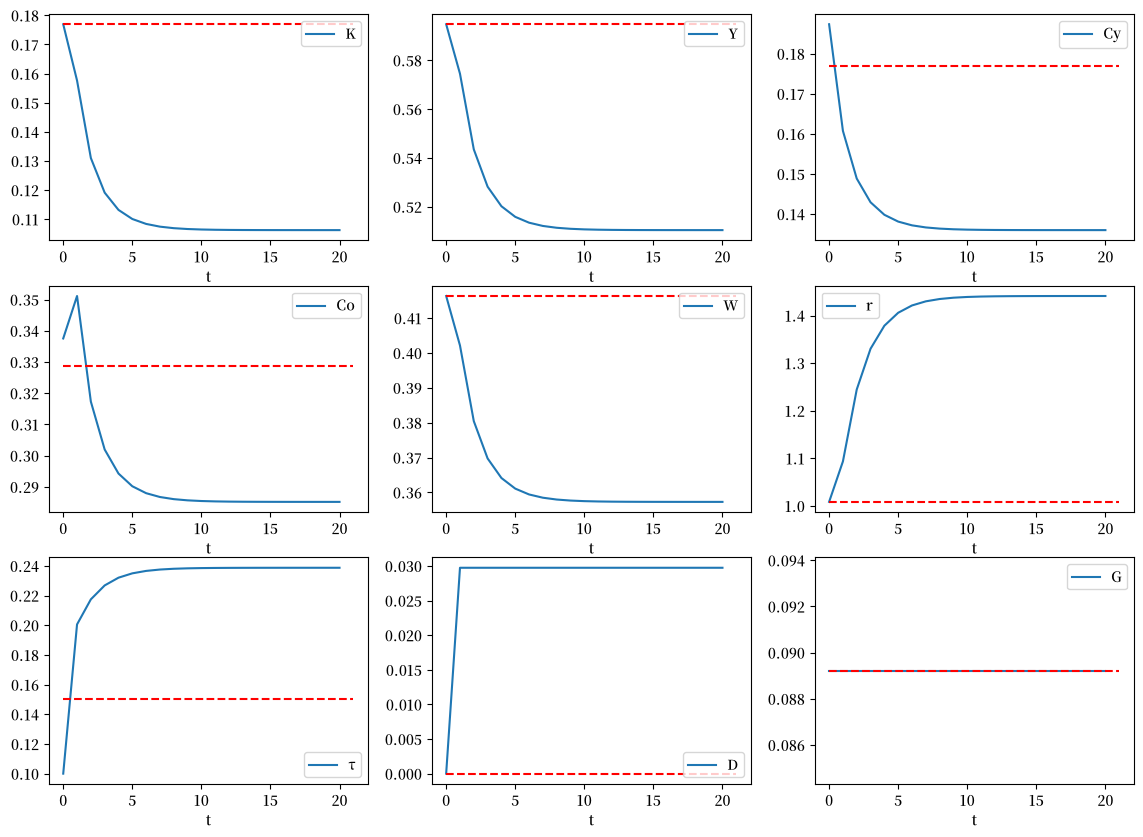

In [12]:
quant_seq1, price_seq1, policy_seq1 = closed.simulate(T, init_ss,
                                                      D_pol=D_seq,
                                                      G_pol=G_seq)
closed.plot()

我们也可以尝试更低的减税率，例如 $0.2$。

In [13]:
# 更低的减税率
τ0 = 0.15 * (1 - 0.2)

# 相应的债务序列
D_bar = G_hat - τ0 * Y_hat
D_seq = np.ones(T+2) * D_bar
D_seq[0] = D_hat

quant_seq2, price_seq2, policy_seq2 = closed.simulate(T, init_ss,
                                                      D_pol=D_seq,
                                                      G_pol=G_seq)

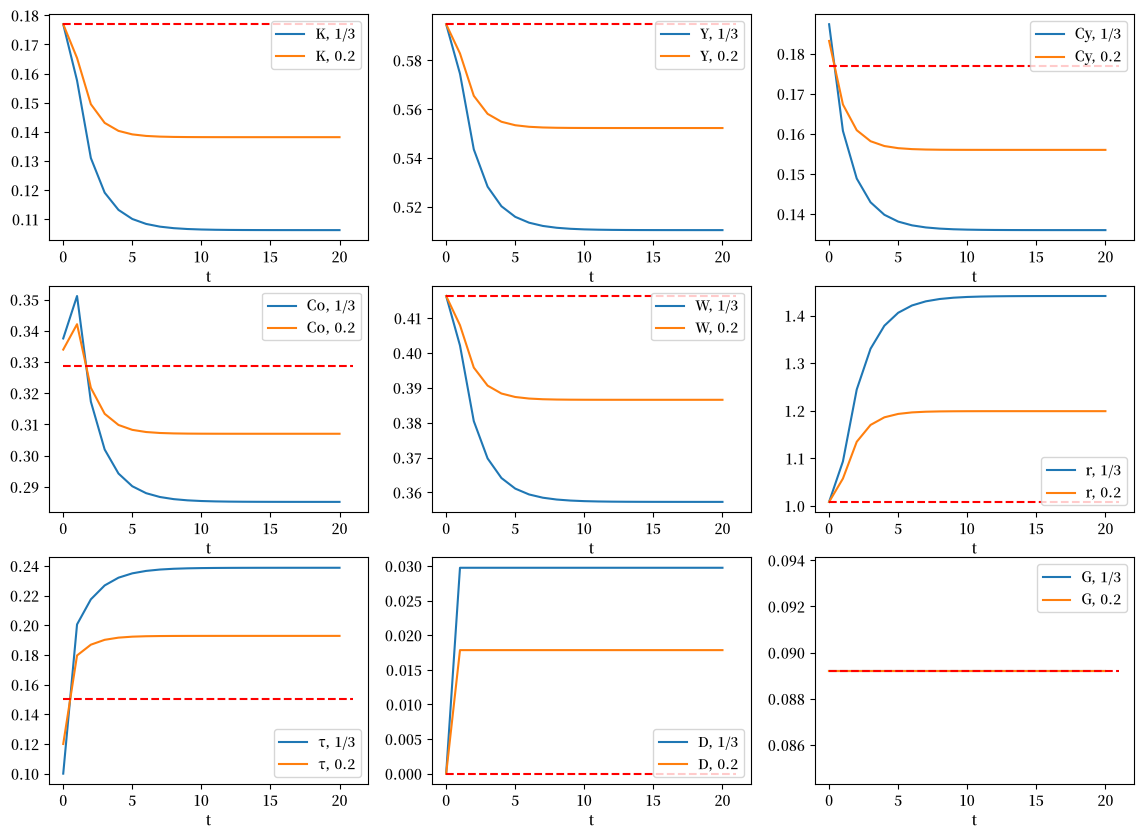

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(14, 10))

# 数量
for i, name in enumerate(['K', 'Y', 'Cy', 'Co']):
    ax = axs[i//3, i%3]
    ax.plot(range(T+1), quant_seq1[:T+1, i], label=f'{name}, 1/3')
    ax.plot(range(T+1), quant_seq2[:T+1, i], label=f'{name}, 0.2')
    ax.hlines(init_ss[i], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

# 价格
for i, name in enumerate(['W', 'r']):
    ax = axs[(i+4)//3, (i+4)%3]
    ax.plot(range(T+1), price_seq1[:T+1, i], label=f'{name}, 1/3')
    ax.plot(range(T+1), price_seq2[:T+1, i], label=f'{name}, 0.2')
    ax.hlines(init_ss[i+4], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

# 政策
for i, name in enumerate(['τ', 'D', 'G']):
    ax = axs[(i+6)//3, (i+6)%3]
    ax.plot(range(T+1), policy_seq1[:T+1, i], label=f'{name}, 1/3')
    ax.plot(range(T+1), policy_seq2[:T+1, i], label=f'{name}, 0.2')
    ax.hlines(init_ss[i+6], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

具有较低减税率（在 $t=0$ 时实施）的经济体，其转型路径模式相同，但扭曲程度较小，并且会收敛到一个拥有更高实物资本存量的新稳态。

(exp-expen-cut)=
### 实验2：政府资产积累

假设经济最初处于相同的稳态。

现在政府承诺将其在公共服务与商品上的支出削减一半，并对所有 $t \geq 0$ 都保持这一削减。

政府设定的目标是保持相同的税率 $\tau_t=\hat{\tau}$，并通过时间推移逐步积累资产 $-D_t$。

为了进行该实验，我们将 `τ_seq` 和 `G_seq` 作为输入，并让 `D_pol` 沿转型路径由政府预算约束自动决定。

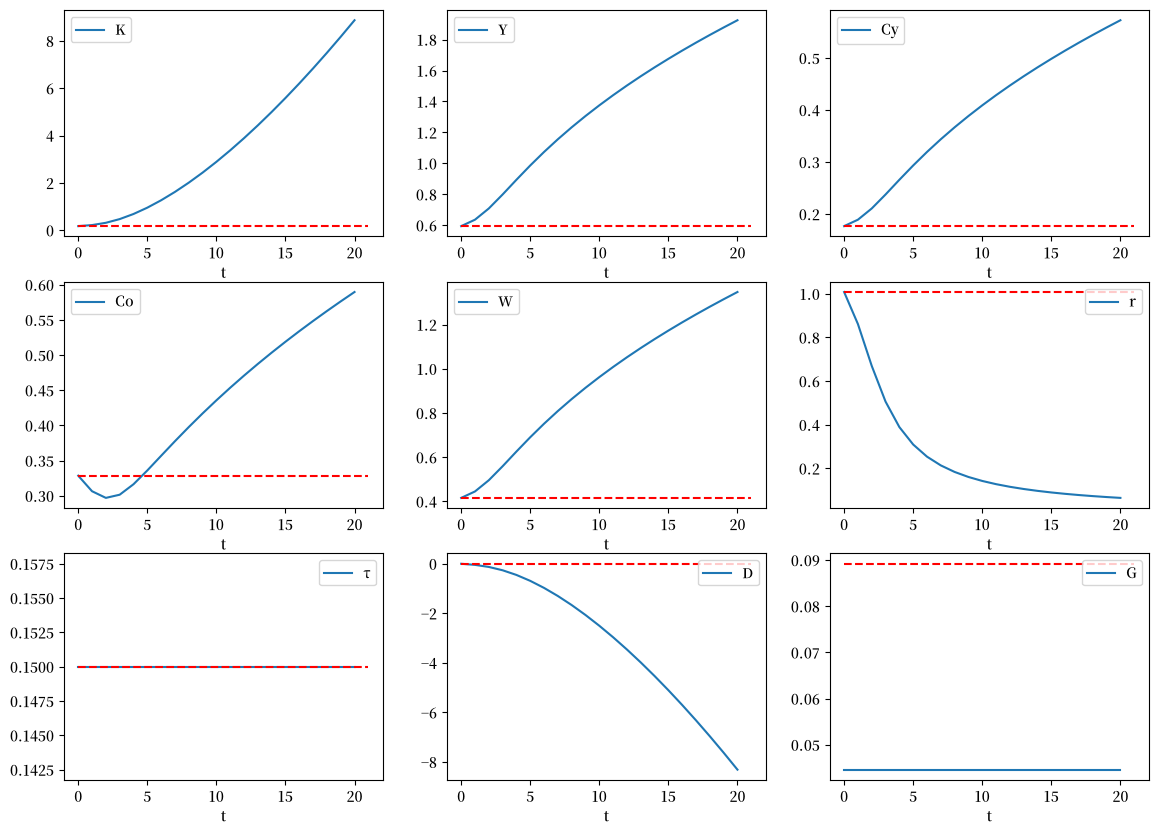

In [15]:
# 政府支出减半
G_seq = τ_hat * 0.5 * Y_hat * np.ones(T+1)

# 目标税率
τ_seq = τ_hat * np.ones(T+1)

closed.simulate(T, init_ss, τ_pol=τ_seq, G_pol=G_seq);
closed.plot()

随着政府积累资产并将其用于生产，资本的租金率下降，私人投资下降。

因此，政府资产与用于生产的实物资本之比 $-\frac{D_t}{K_t}$ 将随着时间的推移而增加

findfont: Failed to find font weight normal, now using 600.


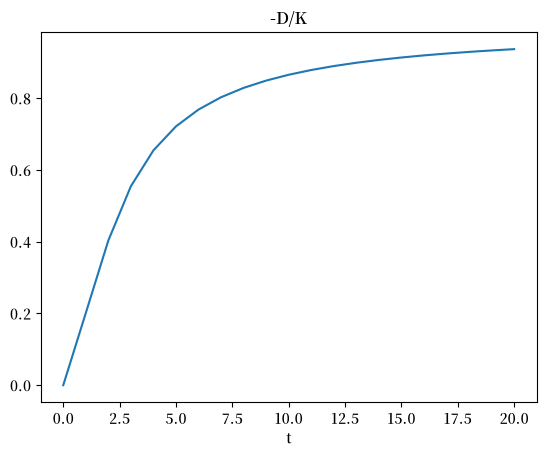

In [16]:
plt.plot(range(T+1), -closed.policy_seq[:-1, 1] / closed.quant_seq[:, 0])
plt.xlabel('t')
plt.title('-D/K');

我们想知道这一政策实验如何影响个体。

从长远来看，未来的世代将在他们的一生中享受更高的消费，因为他们工作时将获得更高的劳动收入。

然而，在短期内，老年人遭受损失，因为劳动收入的增加不足以抵消资本收入的下降。

这种鲜明的长期效应与短期效应促使我们去研究转型路径。

```{note}
虽然在新的稳态中消费确实更高，但其代价是公共服务与商品供给的减少。
```


### 实验3：暂时性支出削减

我们接下来考察一种情形，即政府同样将支出削减一半并积累资产。

但在此实验中，政府只在 $t=0$ 时削减支出。

从 $t \geq 1$ 起，政府支出恢复到 $\hat{G}$，而税率 $\tau_t$ 调整以维持资产水平 $-D_t = -D_1$。

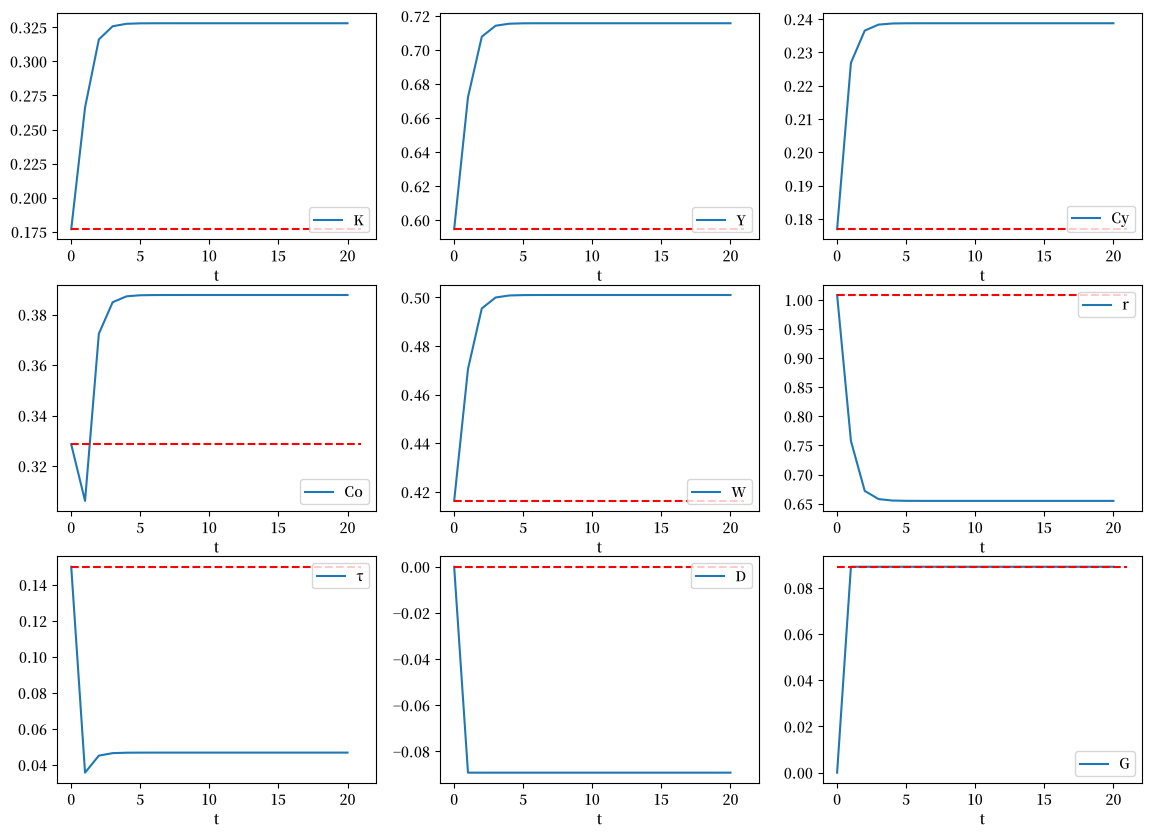

In [17]:
# 政府购买序列
G_seq = τ_hat * Y_hat * np.ones(T+1)
G_seq[0] = 0

# 政府债务序列
D_bar = G_seq[0] - τ_hat * Y_hat
D_seq = D_bar * np.ones(T+2)
D_seq[0] = D_hat

closed.simulate(T, init_ss, D_pol=D_seq, G_pol=G_seq);
closed.plot()

经济体很快收敛到一个新的稳态，在该稳态下，物质资本存量更高、利率更低、工资更高，且年轻人与老年人的消费水平均有所提高。

尽管从 $t \geq 1$ 起，政府支出 $G_t$ 恢复到其较高的初始水平，但由于政府在临时削减支出期间积累了资产，从而获得了额外收入 $-r_t D_t$，因此可以在更低的税率下维持预算平衡。

与 {ref}`exp-expen-cut` 相似，转型期初期的老年人会因该政策冲击而受到损失。


## 计算策略

在前述计算中，我们研究了由不同财政政策引发的动态转型。

在所有这些实验中，我们都保持了一个假设：不存在一次性税收，即 $\delta_{yt}=0, \delta_{ot}=0$。

在本节中，我们将研究当一次性税收存在时的转型动态。

政府将使用一次性税收与转移支付在不同世代之间重新分配资源。

引入一次性税收会破坏封闭形式解，因为此时个体的最优消费与储蓄计划取决于未来价格与税率。

因此，我们通过寻找“从序列到序列的映射”的不动点来计算均衡转型路径：

  * 该不动点确定了一个均衡。

为引入这一寻求其不动点的映射，我们回到 {ref}`sec-equilibrium` 一节中引入的概念。


**定义:** 给定参数 $\{\alpha$, $\beta\}$，一个竞争性均衡由以下内容组成：

* 最优消费序列 $\{C_{yt}, C_{ot}\}$
* 价格序列 $\{W_t, r_t\}$
* 资本存量和产出序列 $\{K_t, Y_t\}$
* 税率、政府资产(债务)、政府购买序列 $\{\tau_t, D_t, G_t\, \delta_{yt}, \delta_{ot}\}$

并满足以下性质：

* 在给定价格体系与政府财政政策下，消费计划是最优的；
* 政府预算约束在所有 $t$ 上均得到满足。

均衡转型路径可以通过“猜测–校验”若干内生序列来计算。

例如，在{ref}`exp-tax-cut`中，序列 $\{D_t\}_{t=0}^{T}$ 和 $\{G_t\}_{t=0}^{T}$ 是外生的。

此外，我们假设一次性税收 $\{\delta_{yt}, \delta_{ot}\}_{t=0}^{T}$ 是给定的，且模型中的每个个体都知晓。

我们可以按照以下步骤求解其他均衡序列

1. 猜测价格 $\{W_t, r_t\}_{t=0}^{T}$ 和税率 $\{\tau_t\}_{t=0}^{T}$；
2. 求解最优消费和储蓄计划 $\{C_{yt}, C_{ot}\}_{t=0}^{T}$，将未来价格和税率的猜测视为真实值；
3. 求解资本存量的转移 $\{K_t\}_{t=0}^{T}$；
4. 用均衡条件隐含的值更新价格和税率的猜测；
5. 迭代直至收敛。

接下来我们将实现这一"猜测和验证"的方法。

我们首先定义 Cobb–Douglas 效用函数

In [18]:
@jit
def U(Cy, Co, β):

    return (Cy ** β) * (Co ** (1-β))

我们使用 `Cy_val` 来计算给定跨期预算约束下任意消费计划 $C_y$ 的终身价值。

注意：这需要知道未来的价格 $r_{t+1}$ 和税率 $\tau_{t+1}$。

In [19]:
@jit
def Cy_val(Cy, W, r_next, τ, τ_next, δy, δo_next, β):

    # Co 由预算约束给出
    Co = (W * (1 - τ) - δy - Cy) * (1 + r_next * (1 - τ_next)) - δo_next

    return U(Cy, Co, β)

最优消费计划 $C_y^*$ 可以通过最大化 `Cy_val` 来找到。

下面是一个计算稳态下最优消费 $C_y^*=\hat{C}_y$ 的例子，其中 $\delta_{yt}=\delta_{ot}=0$，就像我们之前研究的那样。

In [20]:
W, r_next, τ, τ_next = W_hat, r_hat, τ_hat, τ_hat
δy, δo_next = 0, 0

Cy_opt, U_opt, _ = brent_max(Cy_val,            # 最大化的目标函数
                             1e-6,              # 下界
                             W*(1-τ)-δy-1e-6,   # 上界
                             args=(W, r_next, τ, τ_next, δy, δo_next, β))

Cy_opt, U_opt

(0.17694509514972878, 0.241135518231111)

接下来，我们定义一个Python类`AK2`，它可以使用不动点算法计算转型路径。

它可以处理非零一次性税收

In [21]:
class AK2():
    """
    该类模拟一个经济体在给定初始稳态下，对财政政策变化的长度为T的转型路径。
    转型路径通过采用不动点算法来满足均衡条件而得出。

    """

    def __init__(self, α, β):

        self.α, self.β = α, β

    def simulate(self,
                T,           # 模拟的转型路径长度
                init_ss,     # 初始稳态
                δy_seq,      # 年轻人的一次性税收序列
                δo_seq,      # 老年人的一次性税收序列
                τ_pol=None,  # 税率序列
                D_pol=None,  # 政府债务水平序列
                G_pol=None,  # 政府购买序列
                verbose=False,
                max_iter=500,
                tol=1e-5):

        α, β = self.α, self.β

        # 解包稳态变量
        K_hat, Y_hat, Cy_hat, Co_hat = init_ss[:4]
        W_hat, r_hat = init_ss[4:6]
        τ_hat, D_hat, G_hat = init_ss[6:9]

        # K, Y, Cy, Co
        quant_seq = np.empty((T+2, 4))

        # W, r
        price_seq = np.empty((T+2, 2))

        # τ, D, G
        policy_seq = np.empty((T+2, 3))
        policy_seq[:, 1] = D_pol
        policy_seq[:, 2] = G_pol

        # 价格的初始猜测
        price_seq[:, 0] = np.ones(T+2) * W_hat
        price_seq[:, 1] = np.ones(T+2) * r_hat

        # 政策的初始猜测
        policy_seq[:, 0] = np.ones(T+2) * τ_hat

        # t=0, 从稳态开始
        quant_seq[0, :2] = K_hat, Y_hat

        if verbose:
            # 准备绘制迭代直到收敛
            fig, axs = plt.subplots(1, 3, figsize=(14, 4))

        # 检查收敛的容器
        price_seq_old = np.empty_like(price_seq)
        policy_seq_old = np.empty_like(policy_seq)

        # 开始迭代
        i_iter = 0
        while True:

            if verbose:
                # 在第i次迭代时绘制当前价格
                for i, name in enumerate(['W', 'r']):
                    axs[i].plot(range(T+1), price_seq[:T+1, i])
                    axs[i].set_title(name)
                    axs[i].set_xlabel('t')
                axs[2].plot(range(T+1), policy_seq[:T+1, 0],
                            label=f'第{i_iter}次迭代')
                axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
                axs[2].set_title('τ')
                axs[2].set_xlabel('t')

            # 存储上一次迭代的旧价格
            price_seq_old[:] = price_seq
            policy_seq_old[:] = policy_seq

            # 开始更新数量和价格
            for t in range(T+1):
                K, Y = quant_seq[t, :2]
                W, r = price_seq[t, :]
                r_next = price_seq[t+1, 1]
                τ, D, G = policy_seq[t, :]
                τ_next, D_next, G_next = policy_seq[t+1, :]
                δy, δo = δy_seq[t], δo_seq[t]
                δy_next, δo_next = δy_seq[t+1], δo_seq[t+1]

                # 老年人的消费
                Co = (1 + r * (1 - τ)) * (K + D) - δo

                # 年轻人的最优消费
                out = brent_max(Cy_val, 1e-6, W*(1-τ)-δy-1e-6,
                                args=(W, r_next, τ, τ_next,
                                      δy, δo_next, β))
                Cy = out[0]

                quant_seq[t, 2:] = Cy, Co
                τ_num = ((1 + r) * D + G - D_next - δy - δo)
                τ_denom = (Y + r * D)
                policy_seq[t, 0] = τ_num / τ_denom

                # 年轻人的储蓄
                A_next = W * (1 - τ) - δy - Cy

                # K的传导
                K_next = A_next - D_next
                Y_next = K_to_Y(K_next, α)
                W_next, r_next = K_to_W(K_next, α), K_to_r(K_next, α)

                quant_seq[t+1, :2] = K_next, Y_next
                price_seq[t+1, :] = W_next, r_next

            i_iter += 1

            if (np.max(np.abs(price_seq_old - price_seq)) < tol) & \
               (np.max(np.abs(policy_seq_old - policy_seq)) < tol):
                if verbose:
                    print(f"使用{i_iter}次迭代收敛")
                break

            if i_iter > max_iter:
                if verbose:
                    print(f"使用{i_iter}次迭代未能收敛")
                break
        
        self.quant_seq = quant_seq
        self.price_seq = price_seq
        self.policy_seq = policy_seq

        return quant_seq, price_seq, policy_seq

    def plot(self):

        quant_seq = self.quant_seq
        price_seq = self.price_seq
        policy_seq = self.policy_seq

        fig, axs = plt.subplots(3, 3, figsize=(14, 10))

        # 数量
        for i, name in enumerate(['K', 'Y', 'Cy', 'Co']):
            ax = axs[i//3, i%3]
            ax.plot(range(T+1), quant_seq[:T+1, i], label=name)
            ax.hlines(init_ss[i], 0, T+1, color='r', linestyle='--')
            ax.legend()
            ax.set_xlabel('t')

        # 价格
        for i, name in enumerate(['W', 'r']):
            ax = axs[(i+4)//3, (i+4)%3]
            ax.plot(range(T+1), price_seq[:T+1, i], label=name)
            ax.hlines(init_ss[i+4], 0, T+1, color='r', linestyle='--')
            ax.legend()
            ax.set_xlabel('t')

        # 政策
        for i, name in enumerate(['τ', 'D', 'G']):
            ax = axs[(i+6)//3, (i+6)%3]
            ax.plot(range(T+1), policy_seq[:T+1, i], label=name)
            ax.hlines(init_ss[i+6], 0, T+1, color='r', linestyle='--')
            ax.legend()
            ax.set_xlabel('t')

我们用模型参数 $\{\alpha, \beta\}$ 初始化一个 `AK2` 类的实例,然后用它来进行财政政策实验。

In [22]:
ak2 = AK2(α, β)

我们首先检验，当一次性税收被排除时，‘猜测和校验’方法所得的数值结果与封闭形式解所得到的结果一致。

In [23]:
δy_seq = np.ones(T+2) * 0.
δo_seq = np.ones(T+2) * 0.

D_pol = np.zeros(T+2)
G_pol = np.ones(T+2) * G_hat

# 减税
τ0 = τ_hat * (1 - 1/3)
D1 = D_hat * (1 + r_hat * (1 - τ0)) + G_hat - τ0 * Y_hat - δy_seq[0] - δo_seq[0]
D_pol[0] = D_hat
D_pol[1:] = D1

使用10次迭代收敛


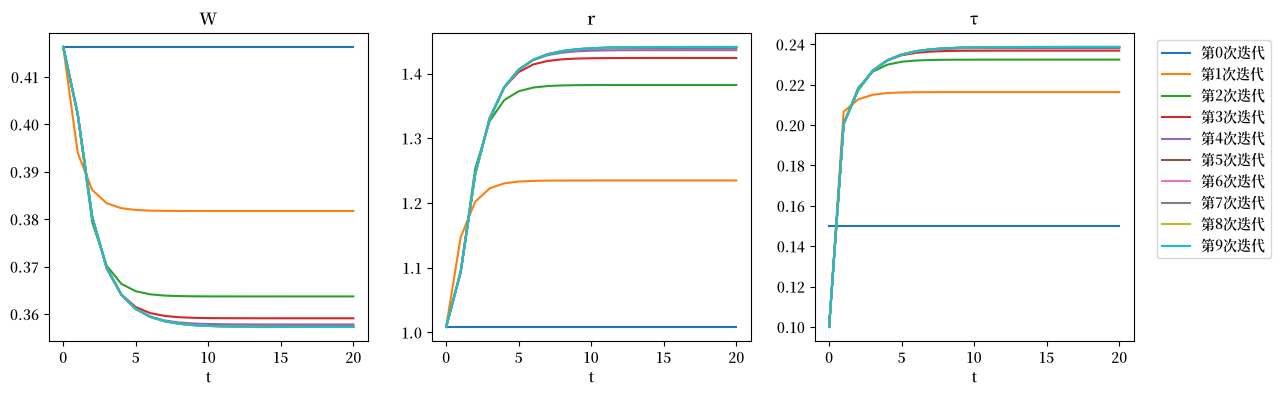

In [24]:
quant_seq3, price_seq3, policy_seq3 = ak2.simulate(T, init_ss,
                                                   δy_seq, δo_seq,
                                                   D_pol=D_pol, G_pol=G_pol,
                                                   verbose=True)

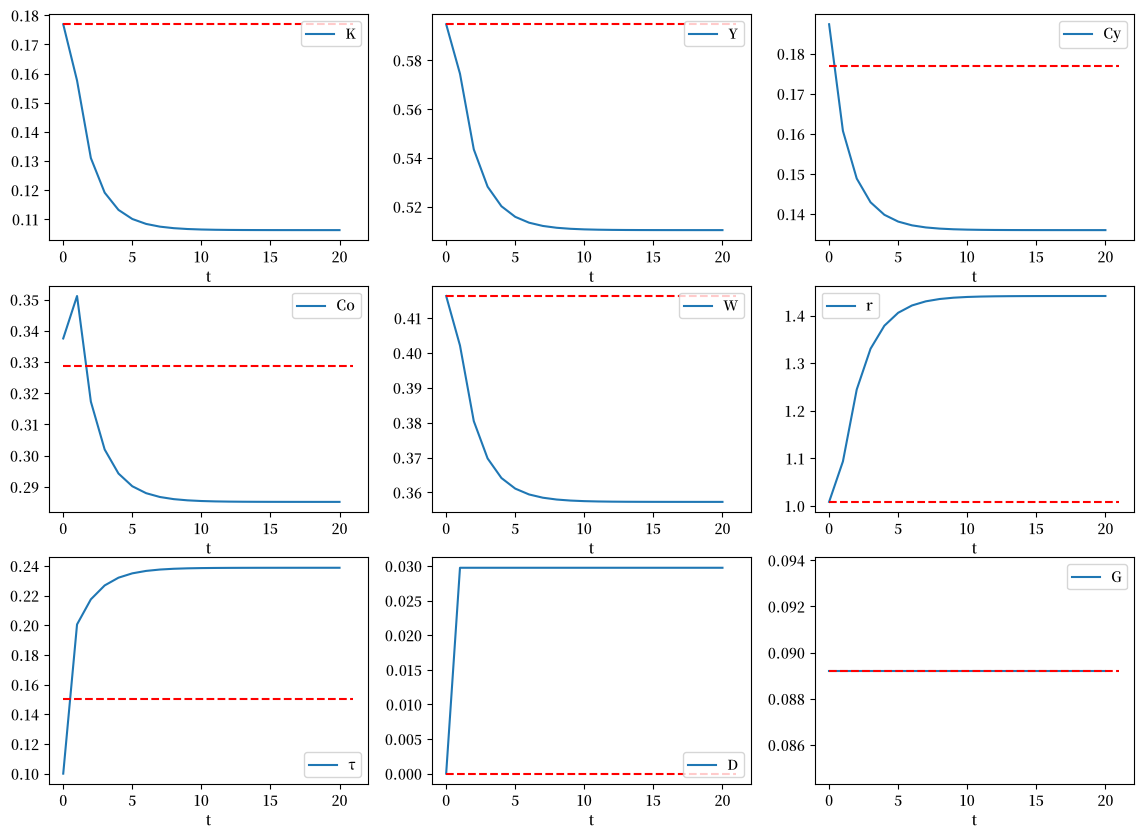

In [25]:
ak2.plot()

接下来,我们引入一次性税收。

让我们修改 {ref}`exp-tax-cut` 中的财政政策设定，假定政府同时对年轻人和老年人提高一次性税收 $\delta_{yt}=\delta_{ot}=0.005, t\geq0$。

In [26]:
δy_seq = np.ones(T+2) * 0.005
δo_seq = np.ones(T+2) * 0.005

D1 = D_hat * (1 + r_hat * (1 - τ0)) + G_hat - τ0 * Y_hat - δy_seq[0] - δo_seq[0]
D_pol[1:] = D1

quant_seq4, price_seq4, policy_seq4 = ak2.simulate(T, init_ss,
                                                   δy_seq, δo_seq,
                                                   D_pol=D_pol, G_pol=G_pol)

注意："挤出效应"已经得到缓解。

findfont: Failed to find font weight normal, now using 600.


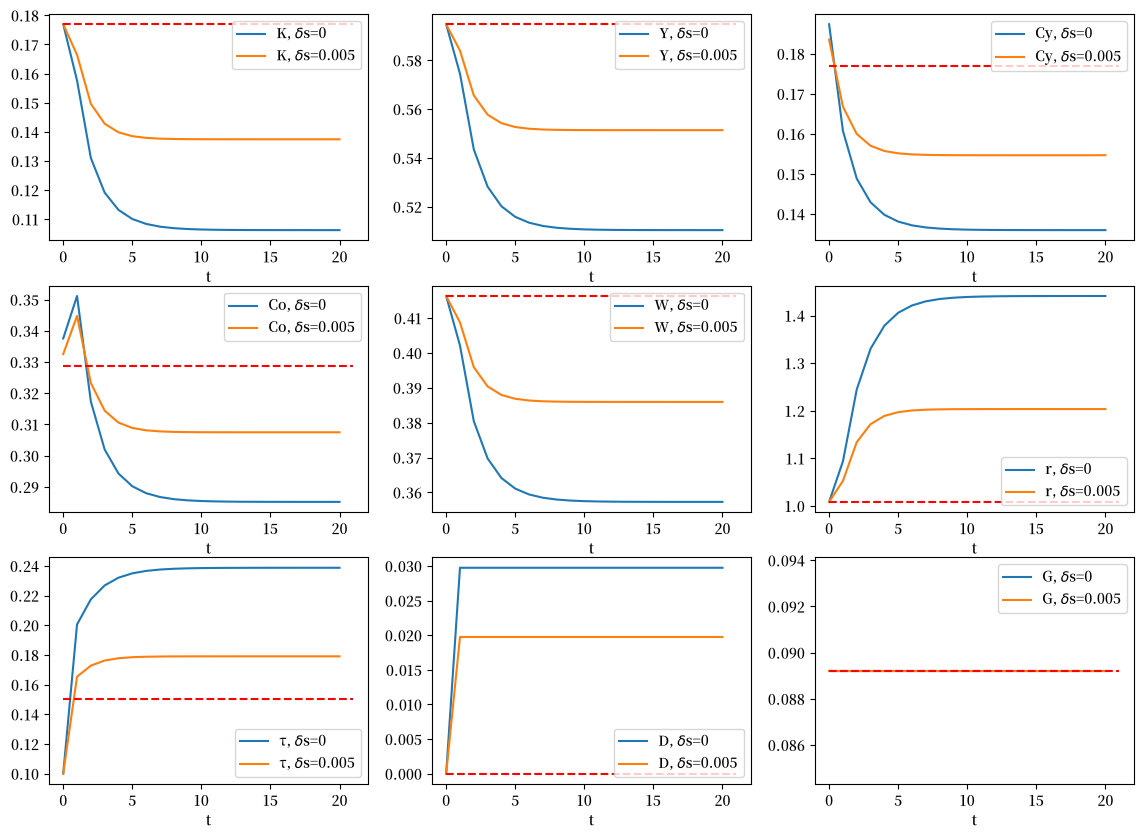

In [27]:
fig, axs = plt.subplots(3, 3, figsize=(14, 10))

# 数量
for i, name in enumerate(['K', 'Y', 'Cy', 'Co']):
    ax = axs[i//3, i%3]
    ax.plot(range(T+1), quant_seq3[:T+1, i], label=rf"{name}, $\delta$s=0")
    ax.plot(range(T+1), quant_seq4[:T+1, i], label=rf"{name}, $\delta$s=0.005")
    ax.hlines(init_ss[i], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

# 价格
for i, name in enumerate(['W', 'r']):
    ax = axs[(i+4)//3, (i+4)%3]
    ax.plot(range(T+1), price_seq3[:T+1, i], label=rf"{name}, $\delta$s=0")
    ax.plot(range(T+1), price_seq4[:T+1, i], label=rf"{name}, $\delta$s=0.005")
    ax.hlines(init_ss[i+4], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

# 政策
for i, name in enumerate(['τ', 'D', 'G']):
    ax = axs[(i+6)//3, (i+6)%3]
    ax.plot(range(T+1), policy_seq3[:T+1, i], label=rf"{name}, $\delta$s=0")
    ax.plot(range(T+1), policy_seq4[:T+1, i], label=rf"{name}, $\delta$s=0.005")
    ax.hlines(init_ss[i+6], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

与 {ref}`exp-tax-cut` 相比，政府提高一次性税收以支付不断增加的债务利息支出，与提高资本所得税税率相比，这种做法的扭曲性更小。


### 实验4：无基金的社会保障制度

在这个实验中，老年人和年轻人的一次性税收数额相等，但符号相反。

负的一次性税收即为补贴。

因此，在这个实验中，年轻人被征税，而老年人获得补贴。

我们将经济体设定在此前若干实验中假定的相同初始稳态。

政府从 $t=0$ 开始设定一次性税收 $\delta_{y,t}=-\delta_{o,t}=10\% \hat{C}_{y}$。

它将债务水平和支出保持在其稳态值 $\hat{D}$ 和 $\hat{G}$。

实际上，这个实验相当于引入一个无基金的社会保障制度。

我们可以使用代码来计算启动这个制度所引发的转型路径。

让我们将其结果与 {ref}`exp-tax-cut` 进行比较。

In [28]:
δy_seq = np.ones(T+2) * Cy_hat * 0.1
δo_seq = np.ones(T+2) * -Cy_hat * 0.1

D_pol[:] = D_hat

quant_seq5, price_seq5, policy_seq5 = ak2.simulate(T, init_ss,
                                                   δy_seq, δo_seq,
                                                   D_pol=D_pol, G_pol=G_pol)

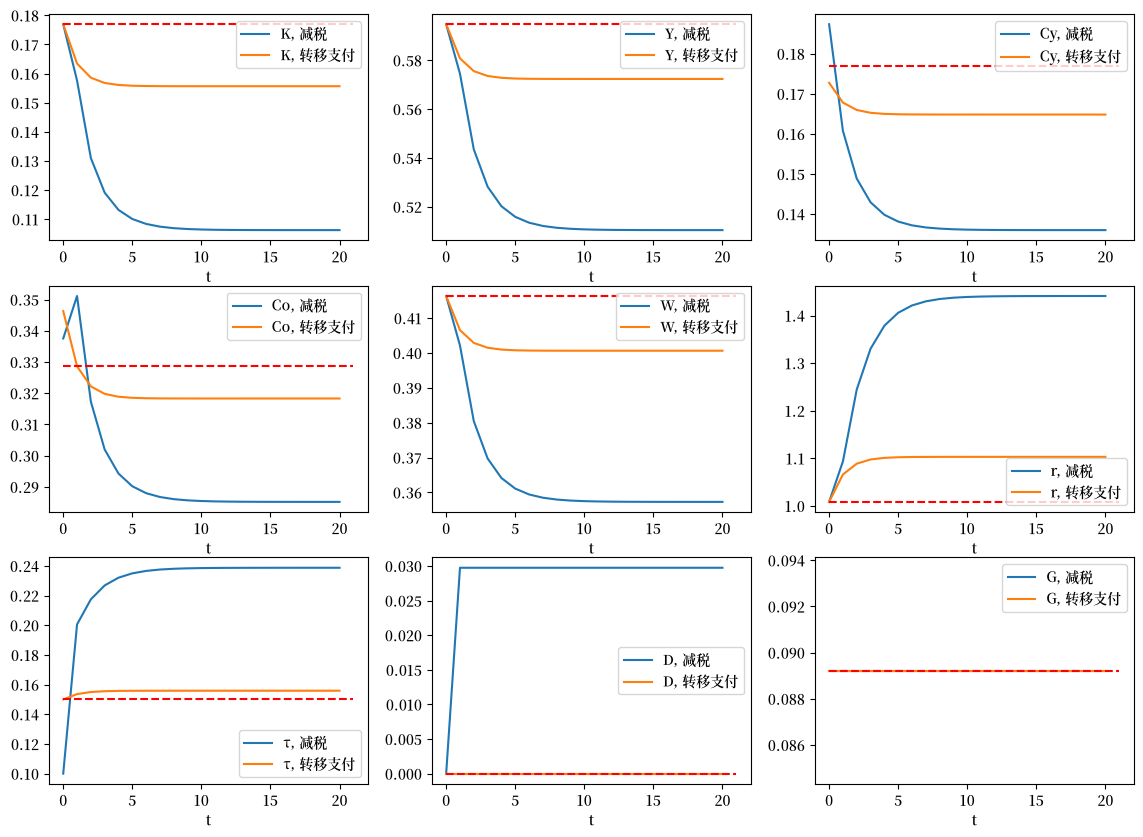

In [29]:
fig, axs = plt.subplots(3, 3, figsize=(14, 10))

# 数量
for i, name in enumerate(['K', 'Y', 'Cy', 'Co']):
    ax = axs[i//3, i%3]
    ax.plot(range(T+1), quant_seq3[:T+1, i], label=f'{name}, 减税')
    ax.plot(range(T+1), quant_seq5[:T+1, i], label=f'{name}, 转移支付')
    ax.hlines(init_ss[i], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

# 价格
for i, name in enumerate(['W', 'r']):
    ax = axs[(i+4)//3, (i+4)%3]
    ax.plot(range(T+1), price_seq3[:T+1, i], label=f'{name}, 减税')
    ax.plot(range(T+1), price_seq5[:T+1, i], label=f'{name}, 转移支付')
    ax.hlines(init_ss[i+4], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

# 政策
for i, name in enumerate(['τ', 'D', 'G']):
    ax = axs[(i+6)//3, (i+6)%3]
    ax.plot(range(T+1), policy_seq3[:T+1, i], label=f'{name}, 减税')
    ax.plot(range(T+1), policy_seq5[:T+1, i], label=f'{name}, 转移支付')
    ax.hlines(init_ss[i+6], 0, T+1, color='r', linestyle='--')
    ax.legend()
    ax.set_xlabel('t')

在社会保障制度启动时，初始老年人尤其受益，因为他获得了转移支付却无需为此支付任何代价。

然而，从长期来看，年轻人与老年人的消费率都会下降，因为社会保障制度削弱了储蓄动机。

这会降低实物资本存量，从而导致产出下降。

为支付其支出，政府必须提高税率。

更高的资本收入税率进一步扭曲了储蓄动机。